# Audience Analysis — Nigeria

**Norman Lear Center × Gates Foundation — Manfluencer project**

This notebook filters and surfaces audience comments that are topically relevant to the masculinity study. It runs a four-signal pipeline over six pre-selected Nigeria posts (3 progressive, 3 regressive creators) and produces a ranked short-list of the ~200 most relevant comments per post for qualitative analysis.

## Pipeline

1. **Load** raw scraped comments (10 posts available → 6 selected).
2. **Basic quality filter** — keep comments that are actually saying something (not pure emoji, URL, or one-word reactions).
3. **Keyword annotation** — loose flag using the NLC Nigeria keyword lexicon (signal, not gate).
4. **Semantic relevance** — OpenAI `text-embedding-3-large` cosine similarity to anchor phrases describing the scope.
5. **LLM classification** — `gpt-4o-mini` judges whether each comment is a meaningful engagement with the post or its topic.
6. **Composite scoring + top-200 selection** per post.
7. **Export** to `Topic Relevant Comments - Nigeria/<Creator>/<Post>.xlsx`.
8. **Report plots**.

## Relevance philosophy (per manager)

> Relevance is harder for this piece because a comment like *"I totally agree with this, it's changing my life"* is relevant despite not having masculinity keywords. But a comment that's like `:eyes:` is not relevant because it won't answer any of our questions. Let's relax the requirements for relevance while still having requirements for 1) at least some words and 2) at least it's saying something / is a sentence.

The filter is therefore **loose** on keyword/topic match and **strict** on substantiveness.


## 0 — Setup

In [1]:
from __future__ import annotations

import asyncio
import json
import os
import re
import time
import unicodedata
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from openai import AsyncOpenAI, OpenAI
from tqdm.asyncio import tqdm as atqdm
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid", context="talk", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

ROOT = Path.cwd().parent if Path.cwd().name == "Notebooks" else Path.cwd()
print("Project root:", ROOT)
load_dotenv(ROOT / ".env")
assert os.getenv("OPENAI_API_KEY"), "OPENAI_API_KEY not set — add it to .env"
print("OpenAI key loaded:", os.getenv("OPENAI_API_KEY")[:8] + "…")


Project root: /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project
OpenAI key loaded: sk-proj-…


## 1 — Config (6 selected posts)

In [2]:
INPUT_DIR = ROOT / "Nigeria Audience Comments"
KEYWORDS_XLSX = ROOT / "Codebook and Keywords" / "NLC Proposed keywords.xlsx"
OUTPUT_DIR = ROOT / "Topic Relevant Comments - Nigeria"
TEMP_DIR = ROOT / "temp" / "audience_analysis"
PLOTS_DIR = ROOT / "Audience Analysis Plots - Nigeria"

TEMP_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EMBEDDING_MODEL = "text-embedding-3-large"
LLM_MODEL = "gpt-4o-mini"
TARGET_PER_POST = 200
LLM_BATCH_SIZE = 20         # comments per LLM request
LLM_CONCURRENCY = 16        # concurrent requests
EMBED_BATCH_SIZE = 256

SELECTED_POSTS = [
    {"creator": "Banky Wellington",  "orientation": "Progressive", "post": "Final Say Faith",                              "file": "Final Say Faith.xlsx",                              "text_col": "comment", "creator_handle": None},
    {"creator": "Banky Wellington",  "orientation": "Progressive", "post": "My Story Journey Through Hope and Faith",      "file": "My Story Journey Through Hope and Faith.xlsx",      "text_col": "comment", "creator_handle": None},
    {"creator": "Deyemi Okanlawon",  "orientation": "Progressive", "post": "Stop Raping Women Response",                   "file": "Stop Raping Women Response.xlsx",                   "text_col": "text",    "creator_handle": "_deyemi"},
    {"creator": "Agba John Doe",     "orientation": "Regressive",  "post": "Never Leave Marriage Because Husband Cheated", "file": "Never Leave Marriage Because Husband Cheated.xlsx", "text_col": "text",    "creator_handle": "jon_d_doe"},
    {"creator": "Shola",             "orientation": "Regressive",  "post": "7 Women Will Beg One Man to Marry",            "file": "7 Women Will Beg One Man to Marry.xlsx",            "text_col": "text",    "creator_handle": "itsSh0la"},
    {"creator": "Wizarab",           "orientation": "Regressive",  "post": "Sex Toys and Raping Young Boys",               "file": "Sex Toys and Raping Young Boys.xlsx",               "text_col": "text",    "creator_handle": "Wizarab10"},
]

print(f"{len(SELECTED_POSTS)} posts selected — 3 Progressive, 3 Regressive")
for p in SELECTED_POSTS:
    print(f"  • {p['creator']:<20} [{p['orientation']:<12}] {p['post']}")


6 posts selected — 3 Progressive, 3 Regressive
  • Banky Wellington     [Progressive ] Final Say Faith
  • Banky Wellington     [Progressive ] My Story Journey Through Hope and Faith
  • Deyemi Okanlawon     [Progressive ] Stop Raping Women Response
  • Agba John Doe        [Regressive  ] Never Leave Marriage Because Husband Cheated
  • Shola                [Regressive  ] 7 Women Will Beg One Man to Marry
  • Wizarab              [Regressive  ] Sex Toys and Raping Young Boys


## 2 — Load raw comments

In [3]:
def _normalize_text(s):
    if not isinstance(s, str):
        return ""
    s = unicodedata.normalize("NFKC", s)
    s = s.replace("\u201c", '"').replace("\u201d", '"')
    s = s.replace("\u2018", "'").replace("\u2019", "'")
    s = re.sub(r"\s+", " ", s).strip()
    return s


def _strip_leading_handle(text, handle):
    # Strip a leading '@handle' that's purely the reply target (not substantive content).
    if not handle or not isinstance(text, str):
        return text
    pattern = re.compile(rf"^\s*@{re.escape(handle)}\b[\s:,.-]*", flags=re.IGNORECASE)
    return pattern.sub("", text).strip()


def _norm_for_ngram(t):
    t = str(t).lower()
    t = re.sub(r"[^a-z0-9\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()


def _ngrams(t, n=8):
    toks = t.split()
    return {" ".join(toks[i:i + n]) for i in range(len(toks) - n + 1)} if len(toks) >= n else {t}


def load_post(meta):
    path = INPUT_DIR / meta["creator"] / meta["file"]
    df = pd.read_excel(path)
    handle = meta.get("creator_handle")

    # Drop any row authored by the creator themselves — that is the original post or a thread continuation.
    dropped_op = 0
    op_ngrams = set()
    if handle and "author" in df.columns:
        mask = df["author"].astype(str).str.lower() == handle.lower()
        dropped_op = int(mask.sum())
        for t in df.loc[mask, meta["text_col"]].astype(str):
            op_ngrams |= _ngrams(_norm_for_ngram(t))
        df = df.loc[~mask].reset_index(drop=True)

    df["raw_text"] = df[meta["text_col"]].apply(_normalize_text)
    if handle:
        df["raw_text"] = df["raw_text"].apply(lambda t: _strip_leading_handle(t, handle))

    # Drop pull-quote comments that just repeat the OP verbatim with no added content.
    dropped_quotes = 0
    if op_ngrams:
        def is_quote(t):
            ng = _ngrams(_norm_for_ngram(t))
            if not ng:
                return False
            overlap = len(ng & op_ngrams) / len(ng)
            return overlap >= 0.5 and len(_norm_for_ngram(t).split()) >= 8
        quote_mask = df["raw_text"].apply(is_quote)
        dropped_quotes = int(quote_mask.sum())
        df = df.loc[~quote_mask].reset_index(drop=True)
    df["creator"] = meta["creator"]
    df["orientation"] = meta["orientation"]
    df["post"] = meta["post"]
    keep_cols = ["creator", "orientation", "post", "raw_text"]
    for aux in ("author", "likes", "replies", "retweets", "reply_count", "timestamp", "url"):
        if aux in df.columns:
            keep_cols.append(aux)
            df[aux] = df[aux]

    if dropped_op or dropped_quotes:
        print(f"  · {meta['creator']} :: {meta['post']}: dropped {dropped_op} creator rows + {dropped_quotes} pull-quote rows")
    return df[keep_cols]


raw_frames = [load_post(p) for p in SELECTED_POSTS]
raw = pd.concat(raw_frames, ignore_index=True)
raw_counts = raw.groupby(["creator", "post"]).size().reset_index(name="raw_n")
print(f"Total raw comments across 6 posts (after OP removal): {len(raw):,}")
raw_counts


  · Deyemi Okanlawon :: Stop Raping Women Response: dropped 1 creator rows + 0 pull-quote rows
  · Agba John Doe :: Never Leave Marriage Because Husband Cheated: dropped 10 creator rows + 2 pull-quote rows
  · Shola :: 7 Women Will Beg One Man to Marry: dropped 1 creator rows + 0 pull-quote rows
  · Wizarab :: Sex Toys and Raping Young Boys: dropped 1 creator rows + 0 pull-quote rows
Total raw comments across 6 posts (after OP removal): 9,009


,creator,post,raw_n
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,499
1,Banky Wellington,Final Say Faith,6389
2,Banky Wellington,My Story Journey Through Hope and Faith,712
3,Deyemi Okanlawon,Stop Raping Women Response,646
4,Shola,7 Women Will Beg One Man to Marry,453
5,Wizarab,Sex Toys and Raping Young Boys,310


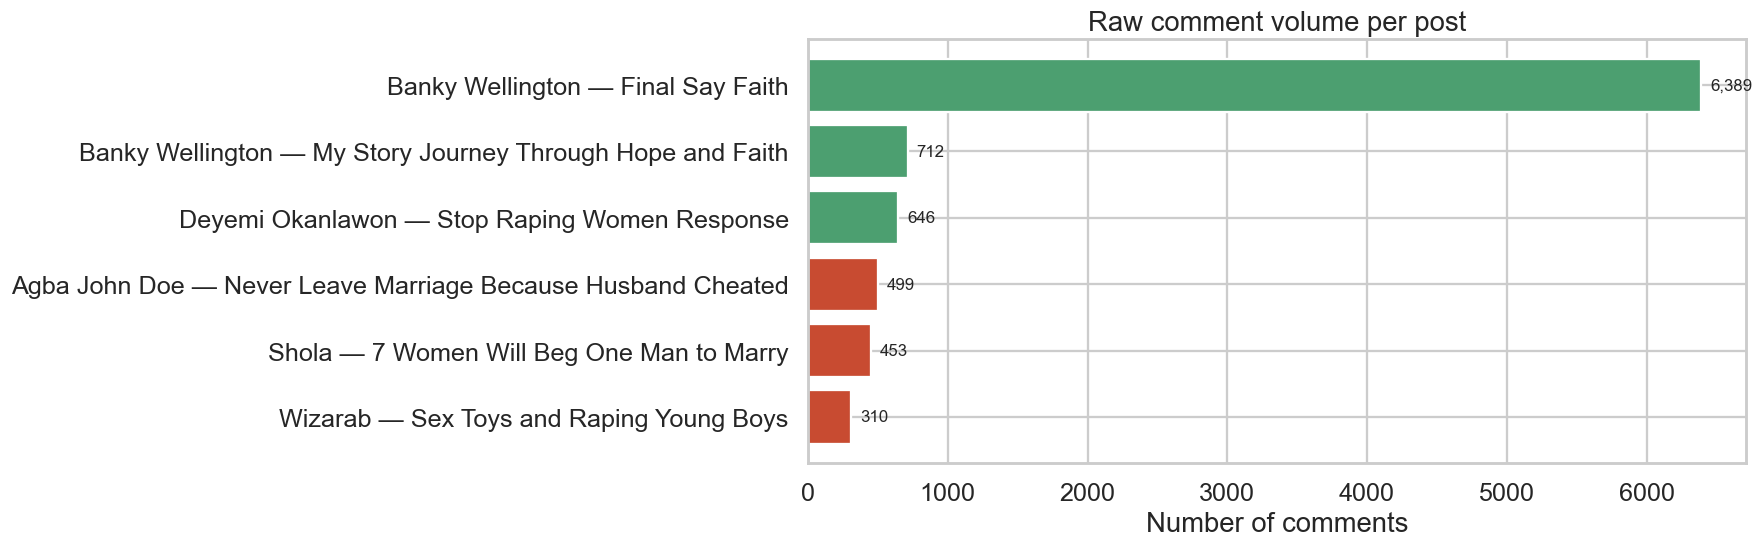

In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
order = raw_counts.sort_values("raw_n", ascending=True)
bars = ax.barh(order["creator"] + " — " + order["post"], order["raw_n"],
               color=["#4C9F70" if o == "Progressive" else "#C84B31"
                      for o in order.merge(raw.drop_duplicates(["creator", "post"])[["creator", "post", "orientation"]],
                                            on=["creator", "post"])["orientation"]])
ax.set_title("Raw comment volume per post")
ax.set_xlabel("Number of comments")
for bar, n in zip(bars, order["raw_n"]):
    ax.text(bar.get_width() + max(order["raw_n"]) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{n:,}", va="center", fontsize=11)
plt.savefig(PLOTS_DIR / "01_raw_volume.png")
plt.show()


## 3 — Basic quality filter

We drop comments that can't answer any research question: pure emoji, URL-only, mention-only, one-word reactions, or under ~3 meaningful words.

We **keep** short-but-substantive reactions like *"I totally agree"*, *"Bitter truth"*, *"Thanks for this"* — these are valid audience reactions.


In [5]:
EMOJI_PATTERN = re.compile(
    "[\U0001F300-\U0001FAFF\U0001F600-\U0001F64F\U0001F680-\U0001F6FF"
    "\U00002600-\U000027BF\U0001F900-\U0001F9FF\U00002700-\U000027BF"
    "\U0001F100-\U0001F1FF]+",
    flags=re.UNICODE,
)
URL_PATTERN = re.compile(r"https?://\S+|www\.\S+|\S+\.(com|co|ng|org|io)/\S*", flags=re.IGNORECASE)
MENTION_PATTERN = re.compile(r"@\w+")
HASHTAG_PATTERN = re.compile(r"#\w+")


def strip_decorations(s):
    s = URL_PATTERN.sub(" ", s)
    s = MENTION_PATTERN.sub(" ", s)
    s = EMOJI_PATTERN.sub(" ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def quality_signals(text):
    stripped = strip_decorations(text)
    words = re.findall(r"[A-Za-z']+", stripped)
    n_words = len(words)
    n_alpha = sum(1 for w in words if any(c.isalpha() for c in w))
    longest = max((len(w) for w in words), default=0)
    total_chars = len(stripped)
    return pd.Series({
        "stripped_text": stripped,
        "n_words": n_words,
        "n_alpha_words": n_alpha,
        "longest_word_len": longest,
        "stripped_chars": total_chars,
    })


def is_substantive(row):
    if row["stripped_chars"] < 8:
        return False
    if row["n_words"] < 3:
        return False
    if row["n_alpha_words"] < 2:
        return False
    if row["longest_word_len"] < 3:
        return False
    return True


signals = raw["raw_text"].apply(quality_signals)
df = pd.concat([raw, signals], axis=1)
df["is_substantive"] = df.apply(is_substantive, axis=1)

retention = (df.groupby(["creator", "post"])
               .agg(raw=("raw_text", "count"), substantive=("is_substantive", "sum"))
               .reset_index())
retention["drop_rate"] = 1 - retention["substantive"] / retention["raw"]
retention["retention_rate"] = retention["substantive"] / retention["raw"]
print(f"Substantive comments: {int(df['is_substantive'].sum()):,} / {len(df):,} ({df['is_substantive'].mean():.1%})")
retention


Substantive comments: 8,393 / 9,009 (93.2%)


,creator,post,raw,substantive,drop_rate,retention_rate
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,499,452,0.094188,0.905812
1,Banky Wellington,Final Say Faith,6389,5980,0.064016,0.935984
2,Banky Wellington,My Story Journey Through Hope and Faith,712,672,0.056180,0.943820
3,Deyemi Okanlawon,Stop Raping Women Response,646,600,0.071207,0.928793
4,Shola,7 Women Will Beg One Man to Marry,453,411,0.092715,0.907285
5,Wizarab,Sex Toys and Raping Young Boys,310,278,0.103226,0.896774


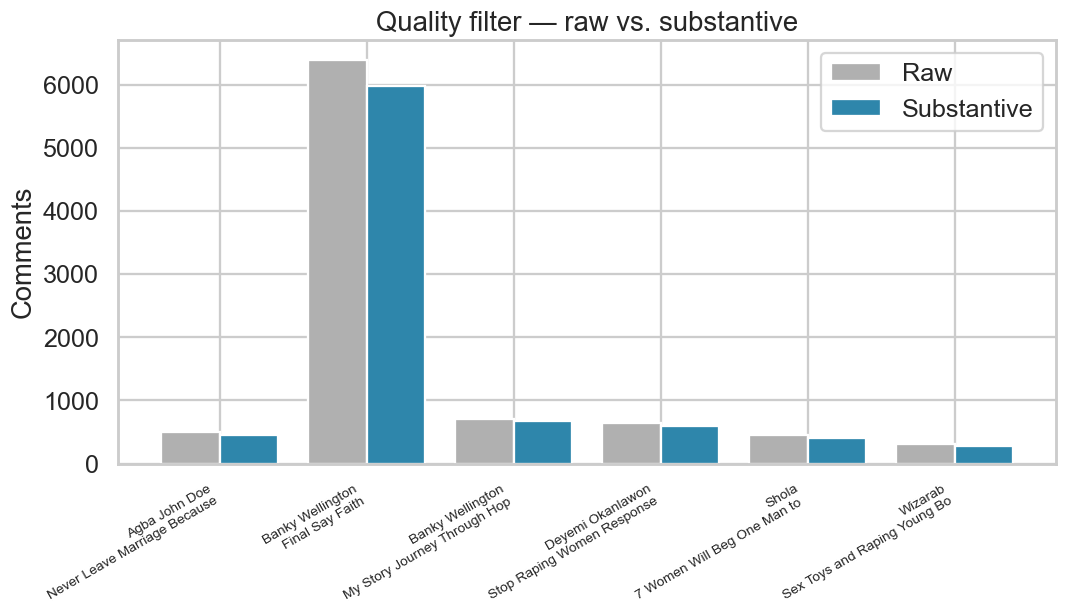

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(retention))
w = 0.4
label_series = retention["creator"] + "\n" + retention["post"].str.slice(0, 28)
ax.bar(x - w/2, retention["raw"], w, label="Raw", color="#B0B0B0")
ax.bar(x + w/2, retention["substantive"], w, label="Substantive", color="#2E86AB")
ax.set_xticks(x)
ax.set_xticklabels(label_series, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Comments")
ax.set_title("Quality filter — raw vs. substantive")
ax.legend()
plt.savefig(PLOTS_DIR / "02_quality_filter.png")
plt.show()


## 4 — Keyword annotation (NLC Nigeria lexicon)

Loose signal, **not** a gate. We flag any comment that matches a Highly/Moderately relevant Nigeria keyword so the downstream scoring can reward keyword hits.


In [7]:
kw_df = pd.read_excel(KEYWORDS_XLSX, sheet_name="Nigeria")
kw_df = kw_df.dropna(subset=["Keyword"])
kw_df["Keyword"] = kw_df["Keyword"].astype(str).str.strip()
kw_df = kw_df[kw_df["Keyword"].str.len() >= 2]

kw_highly = set(kw_df.loc[kw_df["Relevance to manosphere conversations"].str.contains("Highly", na=False), "Keyword"].str.lower())
kw_moderate = set(kw_df.loc[kw_df["Relevance to manosphere conversations"].str.contains("Moderately", na=False), "Keyword"].str.lower())

print(f"Nigeria lexicon: {len(kw_df)} terms")
print(f"  highly relevant: {len(kw_highly)}")
print(f"  moderately relevant: {len(kw_moderate)}")

all_kws = sorted(kw_highly | kw_moderate, key=len, reverse=True)
escaped = [re.escape(k) for k in all_kws]
kw_regex = re.compile(r"\b(" + "|".join(escaped) + r")\b", flags=re.IGNORECASE) if escaped else None


def kw_hits(text):
    if not kw_regex or not text:
        return []
    hits = kw_regex.findall(text.lower())
    return list(dict.fromkeys(hits))  # dedup preserving order


df["keyword_hits"] = df["raw_text"].apply(kw_hits)
df["has_keyword"] = df["keyword_hits"].str.len() > 0
df["n_keyword_hits"] = df["keyword_hits"].str.len()

kw_summary = (df[df["is_substantive"]]
              .groupby(["creator", "post"])
              .agg(substantive=("is_substantive", "sum"),
                   with_keyword=("has_keyword", "sum"))
              .reset_index())
kw_summary["keyword_rate"] = kw_summary["with_keyword"] / kw_summary["substantive"]
kw_summary


Nigeria lexicon: 366 terms
  highly relevant: 246
  moderately relevant: 85


,creator,post,substantive,with_keyword,keyword_rate
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,452,262,0.579646
1,Banky Wellington,Final Say Faith,5980,1657,0.277090
2,Banky Wellington,My Story Journey Through Hope and Faith,672,152,0.226190
3,Deyemi Okanlawon,Stop Raping Women Response,600,226,0.376667
4,Shola,7 Women Will Beg One Man to Marry,411,140,0.340633
5,Wizarab,Sex Toys and Raping Young Boys,278,116,0.417266


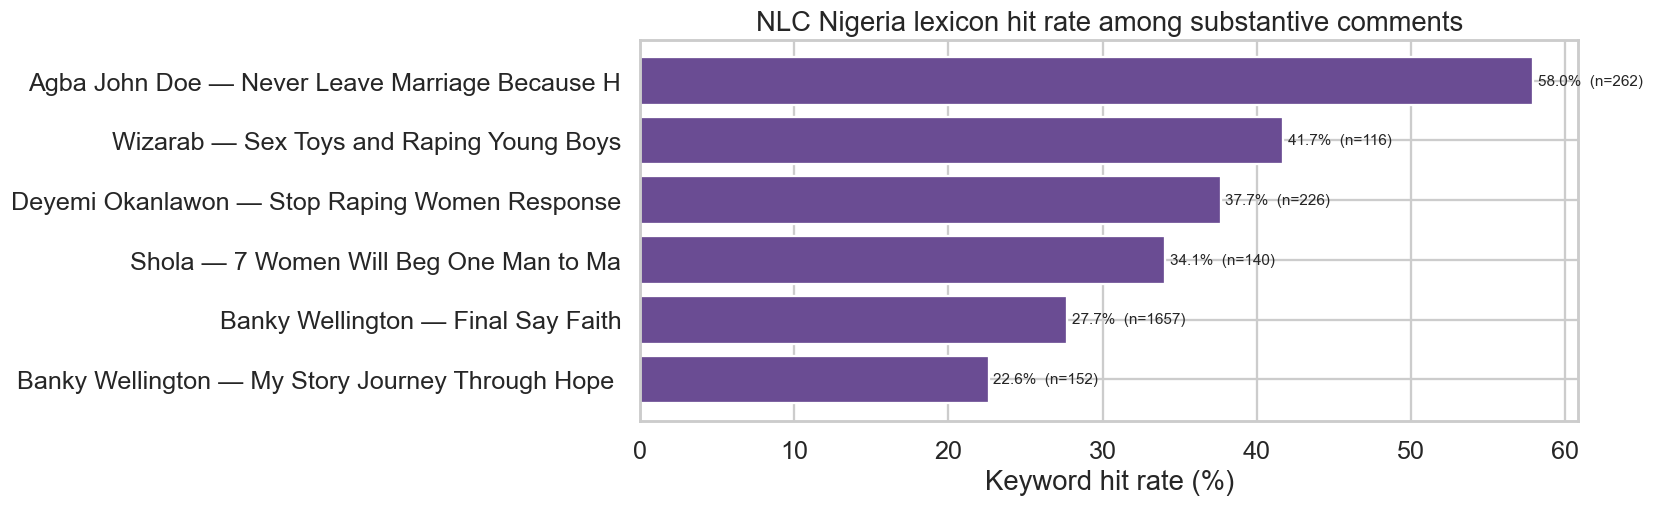

In [8]:
fig, ax = plt.subplots(figsize=(11, 4.5))
rate_order = kw_summary.sort_values("keyword_rate", ascending=True)
ax.barh(rate_order["creator"] + " — " + rate_order["post"].str.slice(0, 30),
        rate_order["keyword_rate"] * 100, color="#6A4C93")
ax.set_xlabel("Keyword hit rate (%)")
ax.set_title("NLC Nigeria lexicon hit rate among substantive comments")
for i, (rate, n) in enumerate(zip(rate_order["keyword_rate"], rate_order["with_keyword"])):
    ax.text(rate * 100 + 0.3, i, f"{rate:.1%}  (n={int(n)})", va="center", fontsize=10)
plt.savefig(PLOTS_DIR / "03_keyword_rate.png")
plt.show()


## 5 — Semantic relevance (OpenAI embeddings)

We embed each substantive comment with `text-embedding-3-large` and compute its maximum cosine similarity to a small set of **anchor phrases** describing the scope. These anchors deliberately cover: masculinity / gender dynamics, relationships and marriage, male emotional life, female agency, faith-framed partnership, gender-based violence, and generic agreement / engagement with the creator's thesis (so short reactions like "I totally agree" still score).


In [9]:
ANCHORS = [
    # Core masculinity
    "views on what it means to be a man",
    "gender roles and masculinity",
    "traditional masculinity and providing for family",
    "progressive masculinity and emotional vulnerability",
    # Relationships & marriage
    "marriage, infidelity and fidelity",
    "dating standards and expectations between men and women",
    "child support, divorce, and parenting responsibilities",
    "polygamy and female scarcity narratives",
    # Violence & accountability
    "rape, sexual violence and accountability",
    "male victimhood and abuse of boys",
    "feminism, misogyny and women's rights",
    # Faith-framed
    "faith, partnership and trust in marriage",
    "religion and gender expectations",
    # Engagement / reaction
    "agreement with the creator or their message",
    "disagreement or pushback against the creator",
    "personal testimony or life story",
    "advice to young men or young women",
]

client = OpenAI()


def embed_batch(texts, model=EMBEDDING_MODEL):
    resp = client.embeddings.create(model=model, input=list(texts))
    return np.array([d.embedding for d in resp.data])


anchor_emb = embed_batch(ANCHORS)
anchor_emb = anchor_emb / np.linalg.norm(anchor_emb, axis=1, keepdims=True)
print("Anchor embeddings:", anchor_emb.shape)


Anchor embeddings: (17, 3072)


In [10]:
sub = df[df["is_substantive"]].copy().reset_index(drop=True)

embeds_path = TEMP_DIR / "comment_embeddings.npy"
if embeds_path.exists() and len(np.load(embeds_path)) == len(sub):
    emb = np.load(embeds_path)
    print(f"Loaded cached embeddings: {emb.shape}")
else:
    emb_list = []
    for start in tqdm(range(0, len(sub), EMBED_BATCH_SIZE), desc="embedding"):
        chunk = sub["stripped_text"].iloc[start:start + EMBED_BATCH_SIZE].tolist()
        emb_list.append(embed_batch(chunk))
    emb = np.vstack(emb_list)
    np.save(embeds_path, emb)
    print("Embeddings:", emb.shape)

emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
sim = emb_norm @ anchor_emb.T
sub["sim_max"] = sim.max(axis=1)
sub["sim_top_anchor"] = [ANCHORS[i] for i in sim.argmax(axis=1)]
sub[["creator", "post", "stripped_text", "sim_max", "sim_top_anchor"]].head()


embedding:   0%|          | 0/33 [00:00<?, ?it/s]

Embeddings: (8393, 3072)


,creator,post,stripped_text,sim_max,sim_top_anchor
0,Banky Wellington,Final Say Faith,I and my husband are next to give this testimo...,0.363459,personal testimony or life story
1,Banky Wellington,Final Say Faith,I have honestly watched this video morethan 10...,0.187181,agreement with the creator or their message
2,Banky Wellington,Final Say Faith,I am marrying well in the name of Jesus Christ,0.415338,"faith, partnership and trust in marriage"
3,Banky Wellington,Final Say Faith,Who is here watching 2024 I keep on watching,0.100626,agreement with the creator or their message
4,Banky Wellington,Final Say Faith,Came back to watch this in 2024. So much truth...,0.186332,agreement with the creator or their message


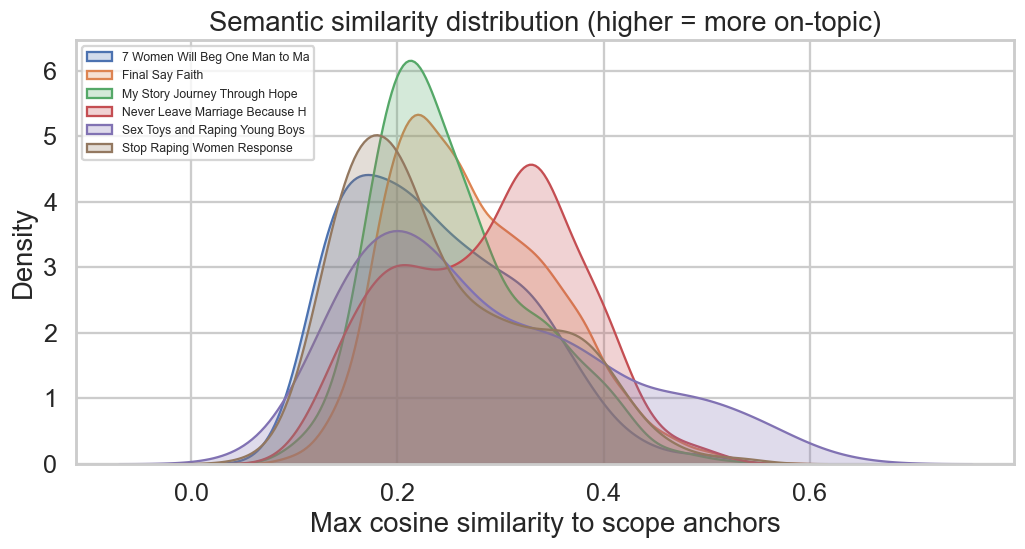

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
for post, g in sub.groupby("post"):
    sns.kdeplot(g["sim_max"], ax=ax, label=post[:30], fill=True, alpha=0.25)
ax.set_xlabel("Max cosine similarity to scope anchors")
ax.set_ylabel("Density")
ax.set_title("Semantic similarity distribution (higher = more on-topic)")
ax.legend(fontsize=8, loc="upper left")
plt.savefig(PLOTS_DIR / "04_similarity_kde.png")
plt.show()


## 6 — LLM relevance classification (GPT-4o-mini)

Each substantive comment is sent to `gpt-4o-mini` in batches of 20. The model returns a JSON array with `{id, relevant, reason}` per comment.

**Prompt criteria (loose):** a comment is `relevant` if it is *any* meaningful engagement with the post's topic — direct discussion, personal testimony, agreement/disagreement, advice, emotional reaction with substance — even if it uses no masculinity keywords. `:eyes:`-style reactions, pure spam, ads, or content unrelated to the post → not relevant.


In [12]:
SYSTEM_PROMPT = '''You are an expert research coder classifying audience comments from Nigerian social media.

A comment is RELEVANT if it is any meaningful engagement with the post's topic or the creator's argument. This includes:
  • Direct discussion of masculinity, gender, relationships, marriage, family, sex, parenting, faith, money, violence, or related themes.
  • Personal testimony or life story prompted by the post.
  • Substantive agreement or disagreement with the creator's position.
  • Advice offered to men or women in response to the post.
  • Emotional reaction that articulates a reason ("this is so true because...", "I relate").

A comment is NOT RELEVANT if it is:
  • Pure emoji, single-word hype, ad/spam, or promotional link.
  • Off-topic chatter about unrelated news, celebrities, or the creator's looks/voice with no substance.
  • Generic praise with zero content ("nice one", "lol").

Be GENEROUS on relevance — short reactions like "I totally agree, this changed my life" or "Bitter truth" ARE relevant.

Return a JSON object with key "results" whose value is a list of objects:
  {"id": <int>, "relevant": true/false, "reason": "<short reason, 12 words max>"}.
Output nothing else.'''


def build_user_prompt(post_title, orientation, batch):
    lines = [f"Post: {post_title}  |  Creator orientation: {orientation}", "", "Comments:"]
    for i, text in batch:
        safe = text.replace("\n", " ")[:400]
        lines.append(f"[{i}] {safe}")
    return "\n".join(lines)


async_client = AsyncOpenAI()


async def classify_batch(task_key, local_to_global, batch, post_title, orientation, sem):
    async with sem:
        for attempt in range(4):
            try:
                resp = await async_client.chat.completions.create(
                    model=LLM_MODEL,
                    temperature=0,
                    response_format={"type": "json_object"},
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT},
                        {"role": "user", "content": build_user_prompt(post_title, orientation, batch)},
                    ],
                )
                data = json.loads(resp.choices[0].message.content)
                items = data.get("results", [])
                out = []
                for r in items:
                    lid = r.get("id")
                    if lid in local_to_global:
                        out.append((local_to_global[lid], bool(r.get("relevant")), r.get("reason", "")))
                return task_key, out
            except Exception as e:
                if attempt == 3:
                    print(f"  LLM batch failed after 4 tries: {e}")
                    return task_key, [(local_to_global[i], None, f"error: {e}") for i, _ in batch]
                await asyncio.sleep(2 ** attempt)


async def classify_all(sub_df):
    sem = asyncio.Semaphore(LLM_CONCURRENCY)
    coroutines = []
    for (creator, post, orient), g in sub_df.groupby(["creator", "post", "orientation"]):
        g_idx = g.index.tolist()
        texts = g["stripped_text"].tolist()
        for start in range(0, len(texts), LLM_BATCH_SIZE):
            chunk_local = list(enumerate(texts[start:start + LLM_BATCH_SIZE], start=start))
            local_to_global = {local_i: g_idx[local_i] for local_i, _ in chunk_local}
            task_key = len(coroutines)
            coroutines.append(classify_batch(task_key, local_to_global, chunk_local, post, orient, sem))

    print(f"Dispatching {len(coroutines)} LLM batches × up to {LLM_BATCH_SIZE} comments each "
          f"({LLM_CONCURRENCY} concurrent)")
    all_rows = []
    tasks = [asyncio.create_task(c) for c in coroutines]
    for fut in atqdm.as_completed(tasks, total=len(tasks), desc="LLM"):
        _, rows = await fut
        all_rows.extend(rows)
    return all_rows


llm_results_path = TEMP_DIR / "llm_results.parquet"
if llm_results_path.exists():
    llm_df = pd.read_parquet(llm_results_path)
    print(f"Loaded cached LLM results: {len(llm_df):,}")
else:
    # Jupyter ships with a running event loop — use top-level await.
    all_rows = await classify_all(sub)
    llm_df = pd.DataFrame(
        [{"sub_idx": idx, "llm_relevant": rel, "llm_reason": reason}
         for idx, rel, reason in all_rows]
    ).drop_duplicates("sub_idx")
    llm_df.to_parquet(llm_results_path)
    print(f"LLM classifications: {len(llm_df):,}")

sub = sub.merge(llm_df, left_index=True, right_on="sub_idx", how="left").drop(columns="sub_idx").reset_index(drop=True)
sub["llm_relevant"] = sub["llm_relevant"].fillna(False).astype(bool)
print(f"LLM-relevant rate: {sub['llm_relevant'].mean():.1%}")


Dispatching 421 LLM batches × up to 20 comments each (16 concurrent)


LLM:   0%|          | 0/421 [00:00<?, ?it/s]

LLM:   0%|          | 1/421 [00:06<47:36,  6.80s/it]

LLM:   1%|          | 4/421 [00:06<09:09,  1.32s/it]

LLM:   2%|▏         | 8/421 [00:07<03:57,  1.74it/s]

...

LLM: 100%|█████████▉| 420/421 [03:29<00:00,  1.67it/s]

LLM: 100%|██████████| 421/421 [03:30<00:00,  2.08it/s]

LLM: 100%|██████████| 421/421 [03:30<00:00,  2.00it/s]

LLM classifications: 8,380
LLM-relevant rate: 55.8%


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_47377/2749756752.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sub["llm_relevant"] = sub["llm_relevant"].fillna(False).astype(bool)


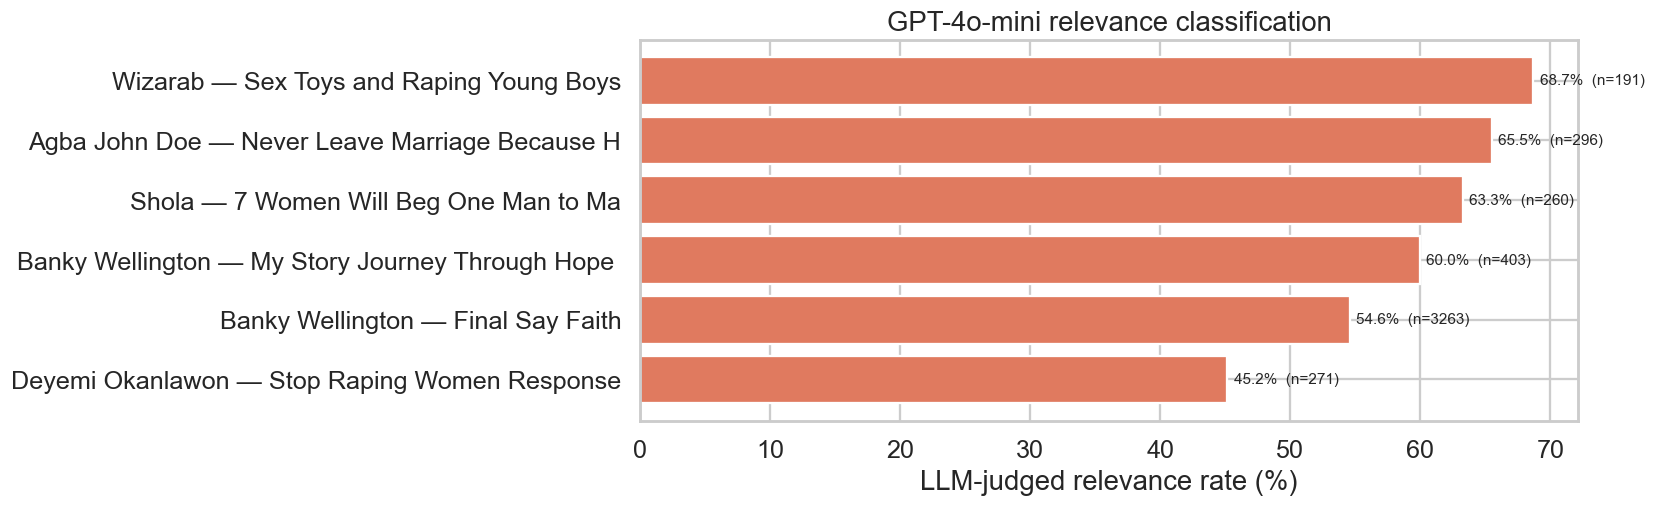

,creator,post,substantive,llm_relevant,llm_rate
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,452,296,0.654867
1,Banky Wellington,Final Say Faith,5980,3263,0.545652
2,Banky Wellington,My Story Journey Through Hope and Faith,672,403,0.599702
3,Deyemi Okanlawon,Stop Raping Women Response,600,271,0.451667
4,Shola,7 Women Will Beg One Man to Marry,411,260,0.632603
5,Wizarab,Sex Toys and Raping Young Boys,278,191,0.687050


In [13]:
llm_summary = (sub.groupby(["creator", "post"])
                .agg(substantive=("llm_relevant", "size"),
                     llm_relevant=("llm_relevant", "sum"))
                .reset_index())
llm_summary["llm_rate"] = llm_summary["llm_relevant"] / llm_summary["substantive"]

fig, ax = plt.subplots(figsize=(11, 4.5))
order = llm_summary.sort_values("llm_rate", ascending=True)
ax.barh(order["creator"] + " — " + order["post"].str.slice(0, 30),
        order["llm_rate"] * 100, color="#E07A5F")
ax.set_xlabel("LLM-judged relevance rate (%)")
ax.set_title("GPT-4o-mini relevance classification")
for i, (r, n) in enumerate(zip(order["llm_rate"], order["llm_relevant"])):
    ax.text(r * 100 + 0.5, i, f"{r:.1%}  (n={int(n)})", va="center", fontsize=10)
plt.savefig(PLOTS_DIR / "05_llm_relevance.png")
plt.show()
llm_summary


## 7 — Composite scoring + top-200 selection

We combine the three signals into a single score, then take the top 200 per post (or all relevant if a post has fewer).

**Score** = `0.25 * keyword_hit + 0.35 * sim_max_scaled + 0.40 * llm_relevant`

- LLM relevance is the dominant signal because it directly matches the manager's definition.
- Embedding similarity breaks ties among LLM-relevant comments.
- Keyword hits nudge up culturally-specific masculinity vocabulary.


In [14]:
# Rescale similarity per-post so high-similarity comments aren't all concentrated in a single topic.
sub["sim_scaled"] = sub.groupby("post")["sim_max"].transform(
    lambda s: (s - s.min()) / (s.max() - s.min() + 1e-9)
)
sub["score"] = (
    0.25 * sub["has_keyword"].astype(float)
    + 0.35 * sub["sim_scaled"]
    + 0.40 * sub["llm_relevant"].astype(float)
)

selected_frames = []
for (creator, post), g in sub.groupby(["creator", "post"]):
    eligible = g[g["llm_relevant"]].copy() if g["llm_relevant"].sum() >= TARGET_PER_POST else g.copy()
    eligible = eligible.sort_values("score", ascending=False)
    top = eligible.head(TARGET_PER_POST).copy()
    top["rank"] = range(1, len(top) + 1)
    selected_frames.append(top)

selected = pd.concat(selected_frames, ignore_index=True)
selection_summary = (selected.groupby(["creator", "post"])
                     .agg(selected=("rank", "size"),
                          avg_score=("score", "mean"),
                          avg_sim=("sim_max", "mean"),
                          kw_rate=("has_keyword", "mean"))
                     .reset_index())
selection_summary


,creator,post,selected,avg_score,avg_sim,kw_rate
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,200,0.865532,0.353694,1.000
1,Banky Wellington,Final Say Faith,200,0.896842,0.431073,1.000
2,Banky Wellington,My Story Journey Through Hope and Faith,200,0.743446,0.322500,0.630
3,Deyemi Okanlawon,Stop Raping Women Response,200,0.795571,0.336027,0.770
4,Shola,7 Women Will Beg One Man to Marry,200,0.711335,0.296336,0.560
5,Wizarab,Sex Toys and Raping Young Boys,200,0.681140,0.323122,0.545


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_47377/2512816861.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(post_labels, rotation=30, ha="right", fontsize=9)


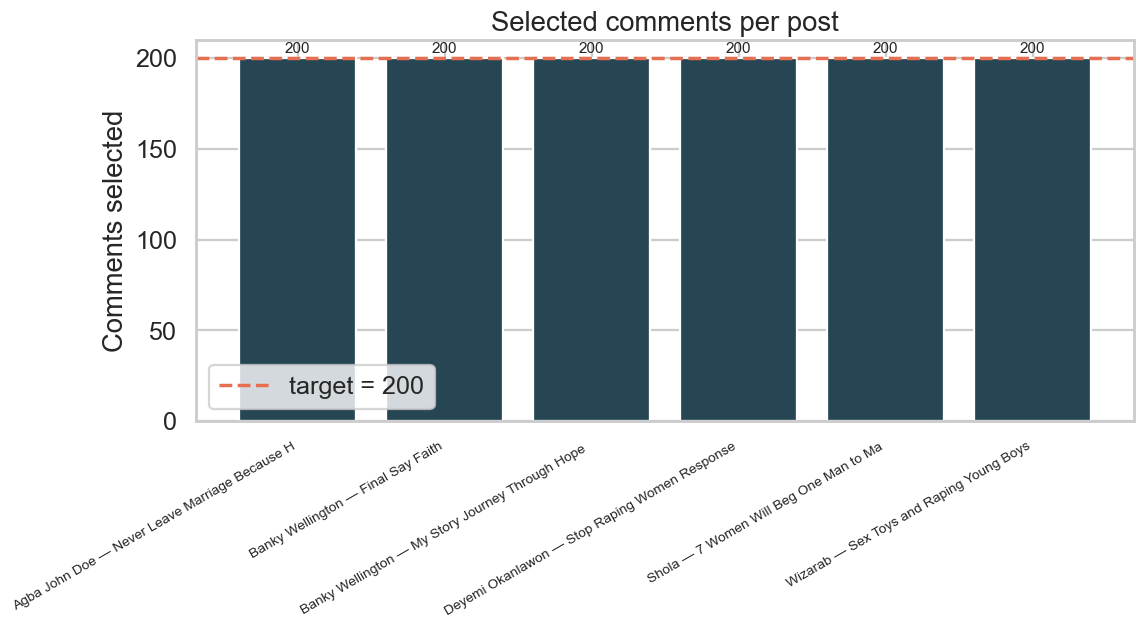

In [15]:
fig, ax = plt.subplots(figsize=(11, 4.5))
post_labels = selection_summary["creator"] + " — " + selection_summary["post"].str.slice(0, 30)
ax.bar(post_labels, selection_summary["selected"], color="#264653")
ax.axhline(TARGET_PER_POST, linestyle="--", color="#E76F51", label=f"target = {TARGET_PER_POST}")
ax.set_xticklabels(post_labels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Comments selected")
ax.set_title("Selected comments per post")
for i, n in enumerate(selection_summary["selected"]):
    ax.text(i, n + 3, f"{int(n)}", ha="center", fontsize=10)
ax.legend()
plt.savefig(PLOTS_DIR / "06_selected_counts.png")
plt.show()


## 8 — Export selected comments

In [16]:
def _safe(name):
    return re.sub(r"[^\w\- ]+", "", name).strip()


summary_rows = []
for (creator, post), g in selected.groupby(["creator", "post"]):
    creator_dir = OUTPUT_DIR / _safe(creator)
    creator_dir.mkdir(parents=True, exist_ok=True)
    out_path = creator_dir / f"{_safe(post)}.xlsx"

    # Only the text column, nothing else.
    out = pd.DataFrame({"text": g.sort_values("rank")["raw_text"].values})
    out.to_excel(out_path, index=False)
    summary_rows.append({"creator": creator, "post": post, "rows": len(out), "path": str(out_path.relative_to(ROOT))})

summary = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / "_summary.xlsx"
summary.to_excel(summary_path, index=False)
print(f"Wrote {len(summary)} files to {OUTPUT_DIR} (text-only)")
summary


Wrote 6 files to /Users/sushildalavi/Desktop/NLC/Gates-Manfluencer-Project/Topic Relevant Comments - Nigeria (text-only)


,creator,post,rows,path
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,200,Topic Relevant Comments - Nigeria/Agba John Do...
1,Banky Wellington,Final Say Faith,200,Topic Relevant Comments - Nigeria/Banky Wellin...
2,Banky Wellington,My Story Journey Through Hope and Faith,200,Topic Relevant Comments - Nigeria/Banky Wellin...
3,Deyemi Okanlawon,Stop Raping Women Response,200,Topic Relevant Comments - Nigeria/Deyemi Okanl...
4,Shola,7 Women Will Beg One Man to Marry,200,Topic Relevant Comments - Nigeria/Shola/7 Wome...
5,Wizarab,Sex Toys and Raping Young Boys,200,Topic Relevant Comments - Nigeria/Wizarab/Sex ...


## 9 — Report-ready plots

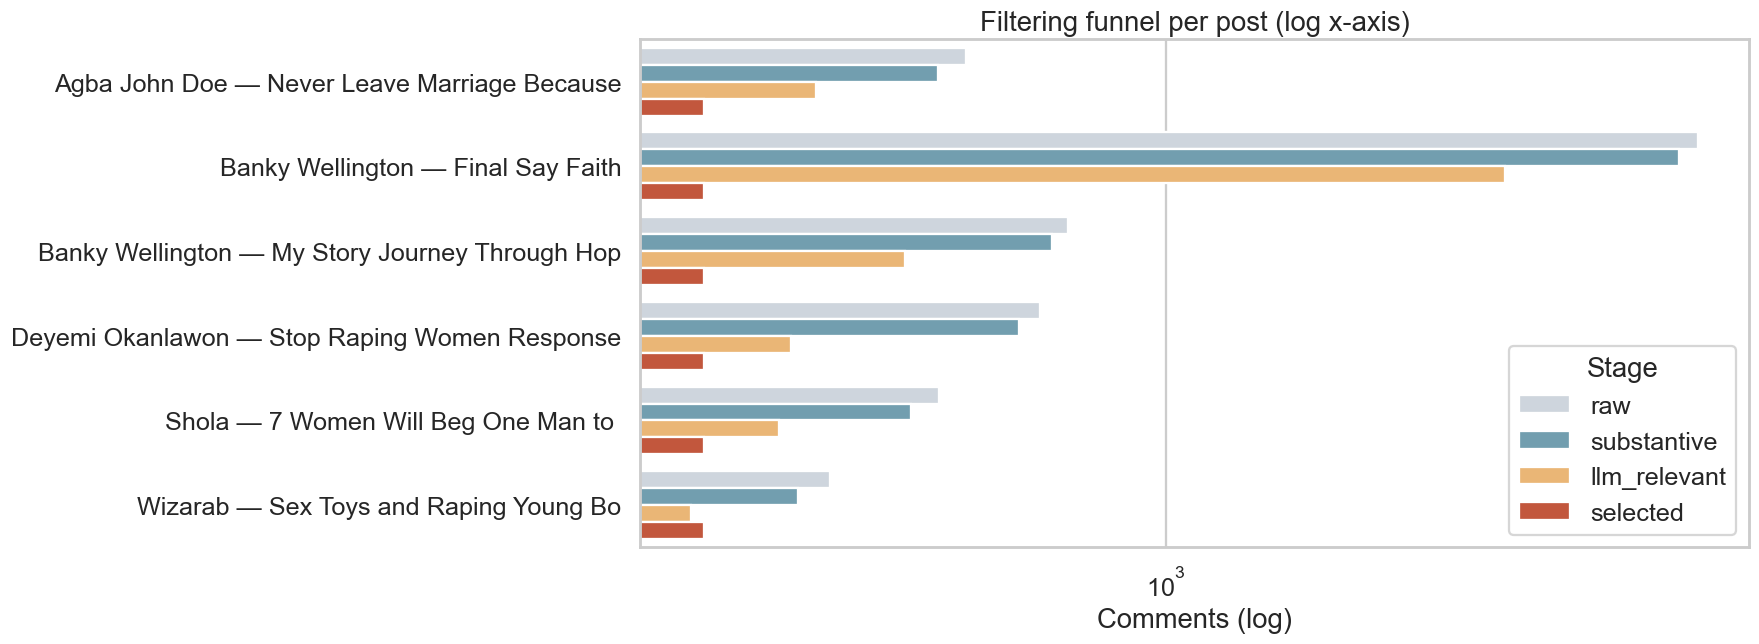

,creator,post,raw,substantive,llm_relevant,selected
0,Agba John Doe,Never Leave Marriage Because Husband Cheated,499,452,296,200
1,Banky Wellington,Final Say Faith,6389,5980,3263,200
2,Banky Wellington,My Story Journey Through Hope and Faith,712,672,403,200
3,Deyemi Okanlawon,Stop Raping Women Response,646,600,271,200
4,Shola,7 Women Will Beg One Man to Marry,453,411,260,200
5,Wizarab,Sex Toys and Raping Young Boys,310,278,191,200


In [17]:
# Combined funnel (raw → substantive → LLM-relevant → selected)
funnel = (raw_counts
    .merge(retention[["creator", "post", "substantive"]], on=["creator", "post"])
    .merge(llm_summary[["creator", "post", "llm_relevant"]], on=["creator", "post"])
    .merge(selection_summary[["creator", "post", "selected"]], on=["creator", "post"])
    .rename(columns={"raw_n": "raw"}))

funnel_melt = funnel.melt(id_vars=["creator", "post"],
                          value_vars=["raw", "substantive", "llm_relevant", "selected"],
                          var_name="stage", value_name="count")
stage_order = ["raw", "substantive", "llm_relevant", "selected"]
funnel_melt["stage"] = pd.Categorical(funnel_melt["stage"], categories=stage_order, ordered=True)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(data=funnel_melt, y=funnel_melt["creator"] + " — " + funnel_melt["post"].str.slice(0, 28),
            x="count", hue="stage", ax=ax, palette=["#CBD5E0", "#68A2B9", "#FDB863", "#D84A27"])
ax.set_xscale("log")
ax.set_title("Filtering funnel per post (log x-axis)")
ax.set_xlabel("Comments (log)")
ax.set_ylabel("")
ax.legend(title="Stage", loc="lower right")
plt.savefig(PLOTS_DIR / "07_funnel.png")
plt.show()
funnel


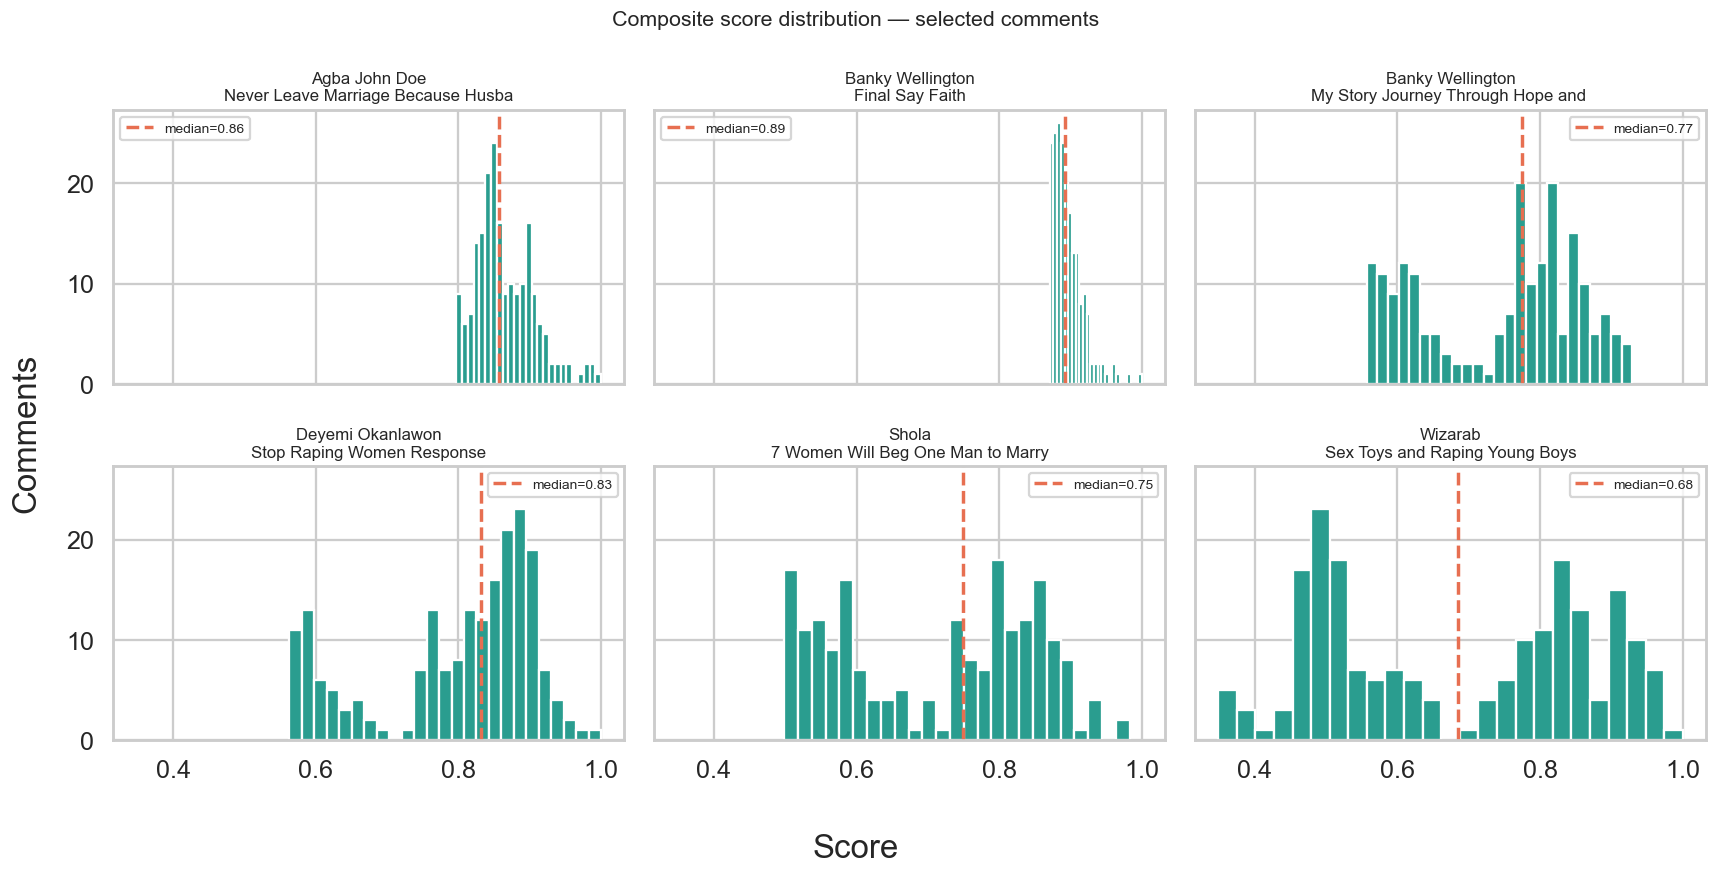

In [18]:
# Score distribution among selected
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
for ax, ((creator, post), g) in zip(axes.flat, selected.groupby(["creator", "post"])):
    ax.hist(g["score"], bins=25, color="#2A9D8F", edgecolor="white")
    ax.axvline(g["score"].median(), color="#E76F51", linestyle="--", label=f"median={g['score'].median():.2f}")
    ax.set_title(f"{creator}\n{post[:34]}", fontsize=11)
    ax.legend(fontsize=9)
fig.suptitle("Composite score distribution — selected comments", fontsize=14)
fig.supxlabel("Score")
fig.supylabel("Comments")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "08_score_distributions.png")
plt.show()


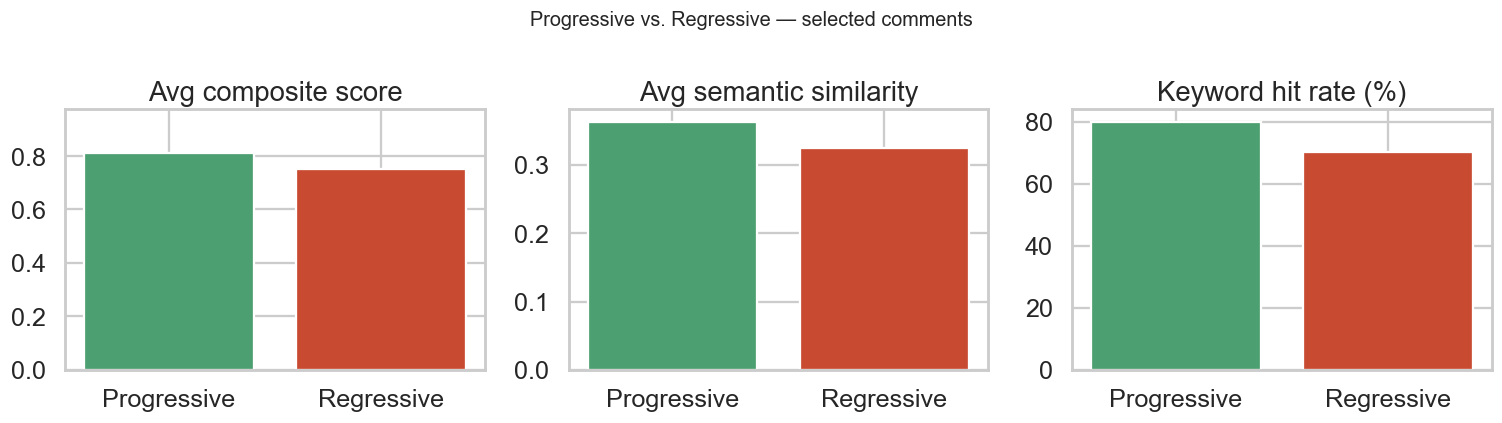

,orientation,n,avg_score,avg_sim,kw_rate,llm_rate
0,Progressive,600,0.811953,0.363200,0.800000,1.000
1,Regressive,600,0.752669,0.324384,0.701667,0.985


In [19]:
# Orientation comparison: avg score + keyword hit
by_orient = selected.groupby("orientation").agg(
    n=("score", "size"),
    avg_score=("score", "mean"),
    avg_sim=("sim_max", "mean"),
    kw_rate=("has_keyword", "mean"),
    llm_rate=("llm_relevant", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].bar(by_orient["orientation"], by_orient["avg_score"], color=["#4C9F70", "#C84B31"])
axes[0].set_title("Avg composite score")
axes[0].set_ylim(0, max(by_orient["avg_score"]) * 1.2)

axes[1].bar(by_orient["orientation"], by_orient["avg_sim"], color=["#4C9F70", "#C84B31"])
axes[1].set_title("Avg semantic similarity")

axes[2].bar(by_orient["orientation"], by_orient["kw_rate"] * 100, color=["#4C9F70", "#C84B31"])
axes[2].set_title("Keyword hit rate (%)")

fig.suptitle("Progressive vs. Regressive — selected comments", fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_orientation_compare.png")
plt.show()
by_orient


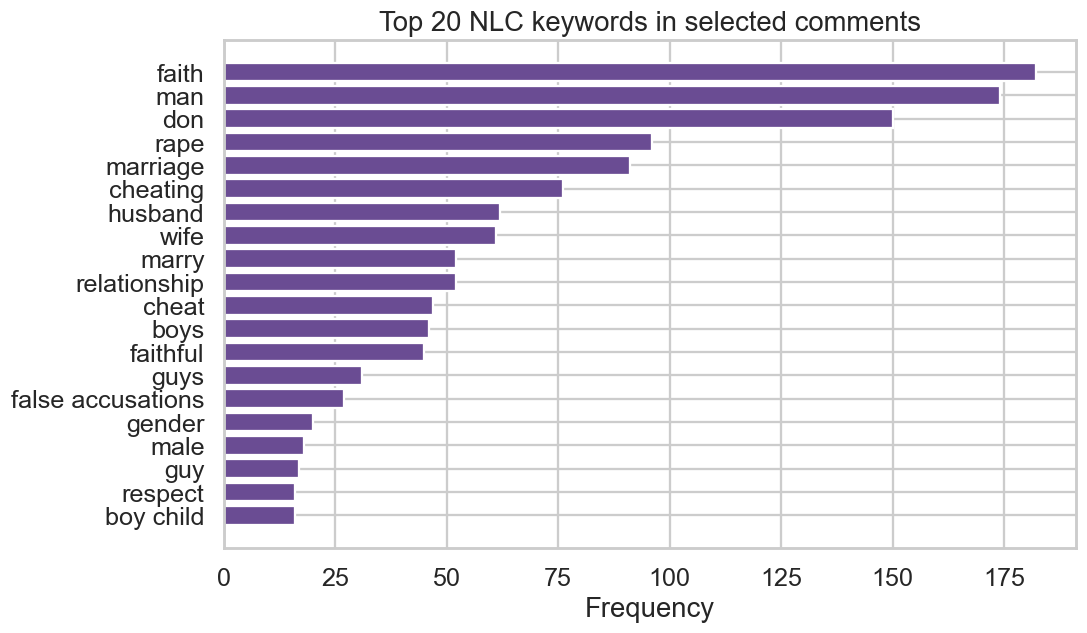

,keyword,count
0,faith,182
1,man,174
2,don,150
3,rape,96
4,marriage,91
5,cheating,76
6,husband,62
7,wife,61
8,marry,52
9,relationship,52


In [20]:
# Top keywords across the selected set
from collections import Counter

kw_counter = Counter()
for hits in selected["keyword_hits"]:
    kw_counter.update(hits)
top_kw = pd.DataFrame(kw_counter.most_common(20), columns=["keyword", "count"])

if len(top_kw):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_kw["keyword"][::-1], top_kw["count"][::-1], color="#6A4C93")
    ax.set_title("Top 20 NLC keywords in selected comments")
    ax.set_xlabel("Frequency")
    plt.savefig(PLOTS_DIR / "10_top_keywords.png")
    plt.show()
top_kw


/var/folders/dv/4yw53xh14jg0_mcrwc977cgm0000gn/T/ipykernel_47377/3638116176.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=selected, y=selected["creator"] + " — " + selected["post"].str.slice(0, 28),


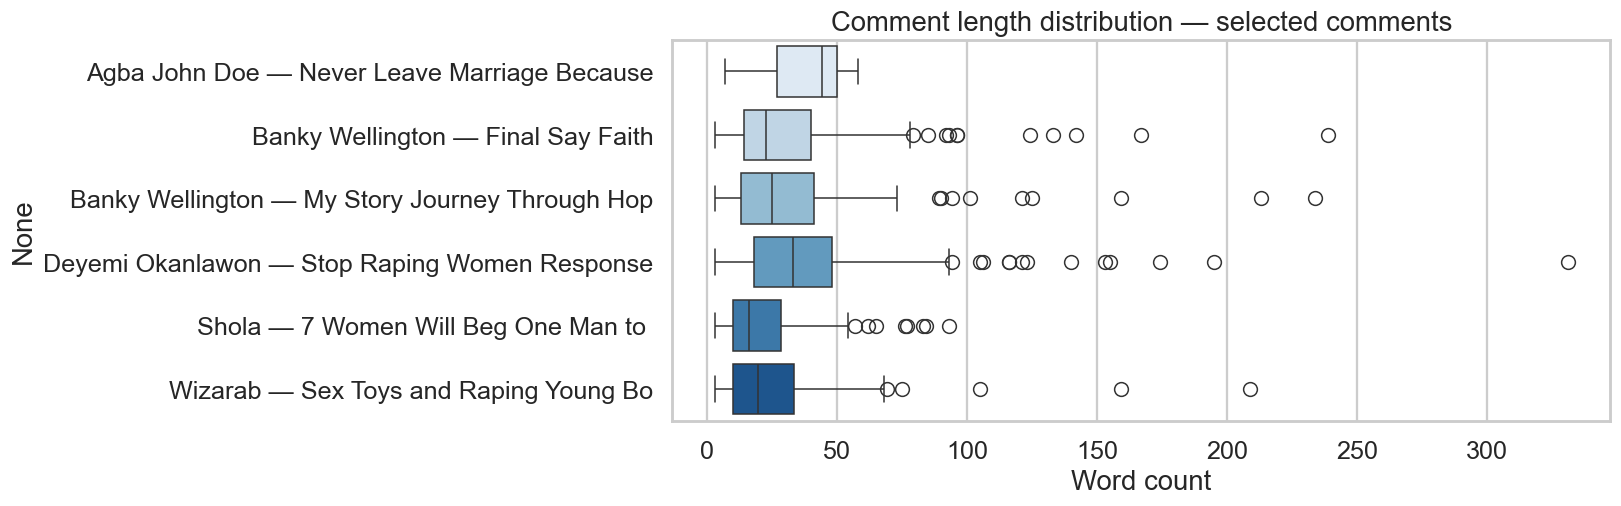

In [21]:
# Word-count distribution of selected comments
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.boxplot(data=selected, y=selected["creator"] + " — " + selected["post"].str.slice(0, 28),
            x="n_words", ax=ax, palette="Blues")
ax.set_xlabel("Word count")
ax.set_title("Comment length distribution — selected comments")
plt.savefig(PLOTS_DIR / "11_length_distribution.png")
plt.show()


## 10 — Extension point: thematic / sentiment LLM analysis (future)

When you're ready to go beyond relevance filtering into thematic coding, plug the selected set into this scaffold. It mirrors the Gates content codebook (attention-getting strategies, masculinity norms, primary topics, solutions, sentiment). The structure below is a working stub — flip `RUN_THEMATIC = True` when you want the additional pass.


In [22]:
RUN_THEMATIC = False  # flip to True to run the thematic pass

CODEBOOK_THEMES = [
    "Dating / marriage",
    "Family / fatherhood",
    "Money / status",
    "Fitness / health",
    "Mental health",
    "Gender issues",
    "Religion / faith",
    "Violence / abuse",
    "Male accountability",
    "Female agency",
]

THEMATIC_SYSTEM_PROMPT = '''You are coding comments against the Gates Content Analysis codebook.
For each comment, return:
  - themes: list of 0–3 themes from the provided codebook (exact strings).
  - sentiment_toward_men: "positive" | "neutral" | "negative".
  - sentiment_toward_women: "positive" | "neutral" | "negative".
  - masculinity_frame: "progressive" | "regressive" | "neutral" | "mixed".
  - stance: "agrees_with_creator" | "disagrees_with_creator" | "unclear".
Return JSON object with key "results" = list of {id, themes, sentiment_toward_men, sentiment_toward_women, masculinity_frame, stance}.'''


async def thematic_batch(batch, post_title, orientation, sem):
    async with sem:
        payload = {"role": "user",
                   "content": build_user_prompt(post_title, orientation, batch) +
                              f"\n\nCodebook themes: {CODEBOOK_THEMES}"}
        resp = await async_client.chat.completions.create(
            model=LLM_MODEL,
            temperature=0,
            response_format={"type": "json_object"},
            messages=[{"role": "system", "content": THEMATIC_SYSTEM_PROMPT}, payload],
        )
        return json.loads(resp.choices[0].message.content).get("results", [])


if RUN_THEMATIC:
    print("Thematic pass would run here — the scaffold mirrors the relevance pass.")
else:
    print("Thematic pass skipped. Flip RUN_THEMATIC = True to enable.")


Thematic pass skipped. Flip RUN_THEMATIC = True to enable.


## Notes

- All API calls are OpenAI (`text-embedding-3-large`, `gpt-4o-mini`).
- Embeddings and LLM verdicts are cached under `temp/audience_analysis/` so re-runs are cheap.
- Plots are written to `temp/audience_analysis/plots/` for embedding in reports.
- Final per-post selections live in `Topic Relevant Comments - Nigeria/<Creator>/<Post>.xlsx` plus `_summary.xlsx`.

Re-run end-to-end: restart kernel → Run All. For full re-compute, delete `temp/audience_analysis/` first.
